# Image reduction Notebook
In this notebook we will reduce our images. For that the steps are: 
1. Create a Master Bias
2. Create a Master Flat
3. Reduce the Science Images

In [1]:
# make figures interactive:
# backend to activate depends on python and jupyter versions.... in doubt try both
# also make sure ipympl is installed
#%matplotlib notebook 
%matplotlib widget
#%matplotlib ipympl
# import library containing image reduction tools for this class
from image_reduction_tools import *
import matplotlib.pyplot as plt
# So we can use the Path
from pathlib import Path
import os


# Lets inspect and set directories 

In [2]:
# 1. Define your base data directory, the path where the data is
data_dir = Path("../../data/photo/") 

# 2. Set up subdirectories for raw science data, biases, flats and reduced data
raw_dir = data_dir / "M1"
bias_dir = data_dir / "offsets"
flat_dir = data_dir / "flats"
output_dir = data_dir / "REDUCED"

# 3. Create the output folder automatically if it doesn't exist
output_dir.mkdir(parents=True, exist_ok=True)

# 4. Use the paths to load or save files
# master_bias_file = cal_dir / "master_bias.fits"
# Grabs all FITS files in raw folder
raw_files = list(raw_dir.glob("*.fits"))  

print(f"Taking input files from: {raw_dir.resolve()}")
print(f"Found {len(raw_files)} raw images to process.")
print(f"Saving intermediate and calibration output files files to: {output_dir.resolve()}")
print(f"Saving science reduced output files to: {output_dir.resolve()}")


Taking input files from: /Users/adanebot/Seafile/Documents/TEACHING/OHP/2026/Astronomical_Data_Reduction/data/photo/M1
Found 9 raw images to process.
Saving intermediate and calibration output files files to: /Users/adanebot/Seafile/Documents/TEACHING/OHP/2026/Astronomical_Data_Reduction/data/photo/REDUCED
Saving science reduced output files to: /Users/adanebot/Seafile/Documents/TEACHING/OHP/2026/Astronomical_Data_Reduction/data/photo/REDUCED


In [3]:
# Let's have a look at what we have in the raw directory
for file in raw_files:
    # remove the path from names to make it a bit cleaner 
    # Use extention .name for the name of the file
    # Use extention .stem for the name of the file without the 'fit' or 'fits' part
    print(file.name)

p43952f1.fits
p43950f1.fits
p43946f1.fits
p43954f1.fits
p43948f1.fits
p43953f1.fits
p43951f1.fits
p43947f1.fits
p43949f1.fits


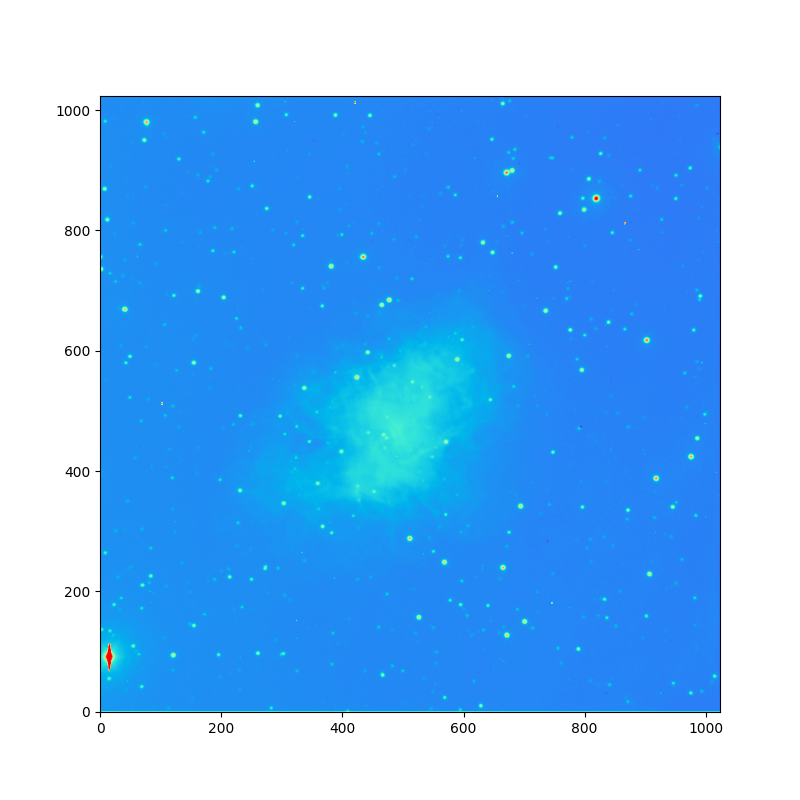

In [4]:
# OK, some files with extension .fits. Let's have a look at one of them
data=read_raw_image(raw_files[0])
plt.figure(figsize=(8,8))
# experiment with different scalings:
# linear
# plt.imshow(data,cmap=cm.gray,norm=None,origin='lower',aspect='auto')
# log
plt.imshow(data,cmap=cm.rainbow,norm=LogNorm(),origin='lower',aspect='auto')
# the origin='lower' option is to have the right orientation.
# it may be different with the most recent camera settings. TBD
plt.show()

Why is this? To investigate that, let's have a look at the dynamics of the image!

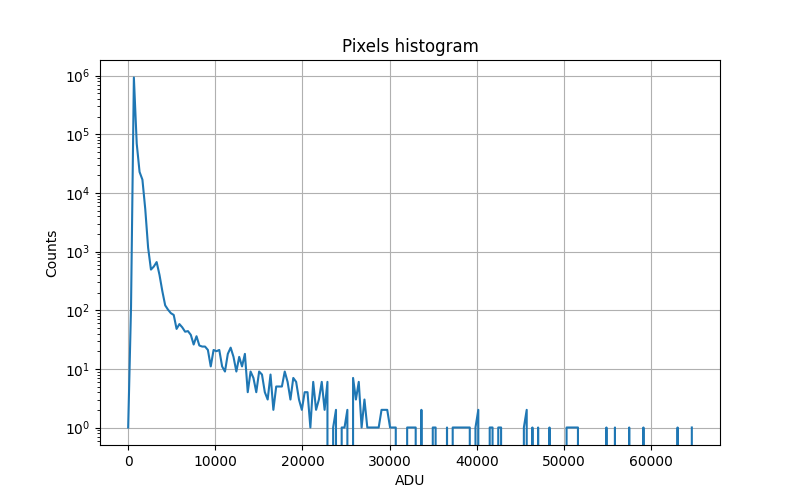

In [5]:
# Histogram to evaluate the frequency of a certain value within the image
bins=np.linspace(0.,65000.,200)
plt.figure(figsize=(8,5))
h,bins=np.histogram(data.flatten(),bins)
plt.plot(bins[:-1],h)
plt.yscale('log')
#plt.xscale('log')
plt.title('Pixels histogram')
plt.xlabel('ADU')
plt.ylabel('Counts')
plt.grid(True)
plt.show()
# discuss the different regimes in the histogram: 
# 1 - what is the large population of darkest pixels?
# 2 - what is the small population of brightest pixels?
# 3 - Where in this plot lives the nebulosity of interest?

In [6]:
# HEADERS! Getting information about the exposures is a vital skill!
# have a look at the header of on of the files for M1
print_header(raw_files[0],l=1)


SIMPLE  =                    T                                                  
BITPIX  =                   32                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 1024                                                  
NAXIS2  =                 1024                                                  
ORIGIN  = 'OHP-LIDO'                                                            
OBJECT  = 'Messier1 / B Cousins /  1200.18  s                         '         
TITLE   = 'POSE SUR LE CIEL             '                                       
DATE    = '19/02/2007                   '                                       
DATE-OBS= '19/02/2007                   '                                       
INSTRUME= 'BNNTT120'                                                            
TELESCOP= 'OHP-120 '                                                            
FOCUS   = '00000000'        

In [7]:
for file in raw_files:
    print_header(file,keywords_list=['OBJECT','FLTRNM','DATE-OBS'], l=0)


 Messier1 / B Cousins /  1200.18  s                     B Cousins 19/02/2007
 Messier1 / R Cousins /  600.17  s                     R Cousins 19/02/2007
 Messier1 / R Cousins /  30.16  s                     R Cousins 19/02/2007
 Messier1 / O3 ohp 5007 /  1200.18  s                   O3 ohp 5007 19/02/2007
 Messier1 / R Cousins /  5.17  s                     R Cousins 19/02/2007
 Messier1 / H Alpha ohp 6565 /  1200.18  s              H Alpha ohp 6565 19/02/2007
 Messier1 / V Cousins /  600.18  s                     V Cousins 19/02/2007
 Messier1 / V Cousins /  60.17  s                     V Cousins 19/02/2007
 Messier1 / R Cousins /  60.17  s                     R Cousins 19/02/2007


In [8]:
# Print a number of selected keywords within the fits file
for file in raw_files:
    print(file)
    print_header(file,keywords_list=['OBJECT'],l=0) # NOTE: relevant keyword to print may change depending on camera software setup


../../data/photo/M1/p43952f1.fits
 Messier1 / B Cousins /  1200.18  s
../../data/photo/M1/p43950f1.fits
 Messier1 / R Cousins /  600.17  s
../../data/photo/M1/p43946f1.fits
 Messier1 / R Cousins /  30.16  s
../../data/photo/M1/p43954f1.fits
 Messier1 / O3 ohp 5007 /  1200.18  s
../../data/photo/M1/p43948f1.fits
 Messier1 / R Cousins /  5.17  s
../../data/photo/M1/p43953f1.fits
 Messier1 / H Alpha ohp 6565 /  1200.18  s
../../data/photo/M1/p43951f1.fits
 Messier1 / V Cousins /  600.18  s
../../data/photo/M1/p43947f1.fits
 Messier1 / V Cousins /  60.17  s
../../data/photo/M1/p43949f1.fits
 Messier1 / R Cousins /  60.17  s


# Create a master bias

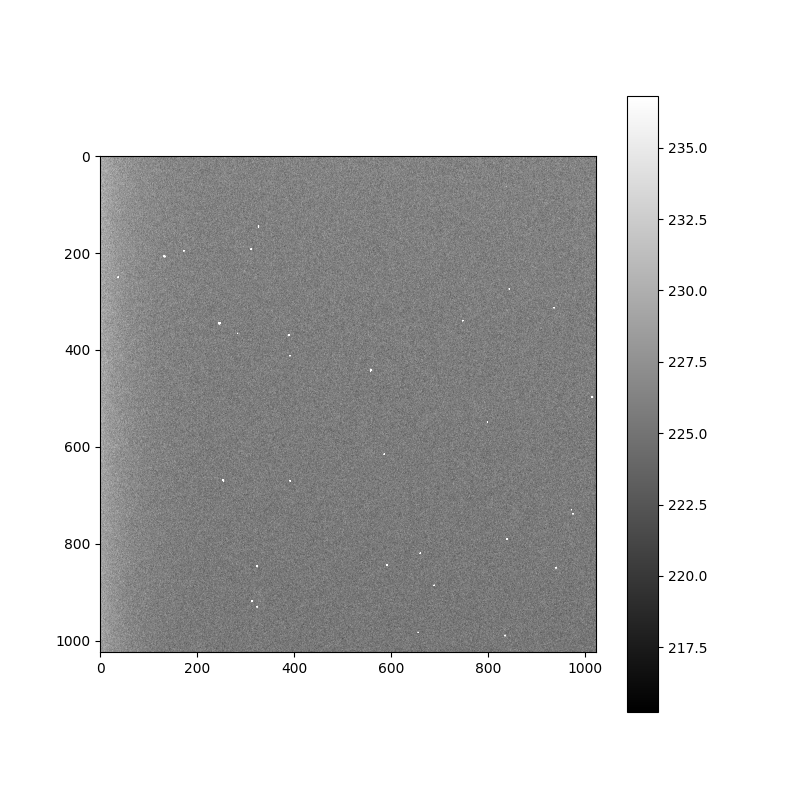

In [9]:
# Let's make a bias
# Load the list of biases and read the first one, have a look at it
bias_files = list(bias_dir.glob("*.fits"))  
data=read_raw_image(bias_files[0])
# what does it look like?
plt.figure(figsize=(8,8))
# setup the cuts of the image
vmin,vmax=get_scaling(data)
plt.imshow(data,cmap=cm.gray,vmin=vmin,vmax=vmax)
plt.colorbar()
plt.show()

# What are all these white dots? do they appear in all images?

What are all these white dots? do they appear in all images?

../../data/photo/offsets/p43958f1.fits


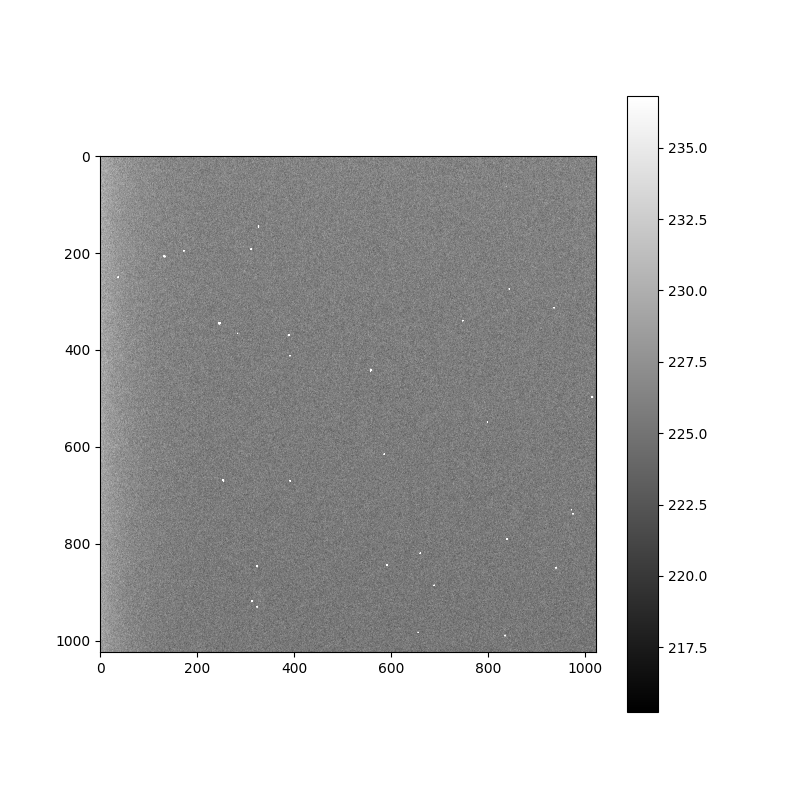

../../data/photo/offsets/p43956f1.fits


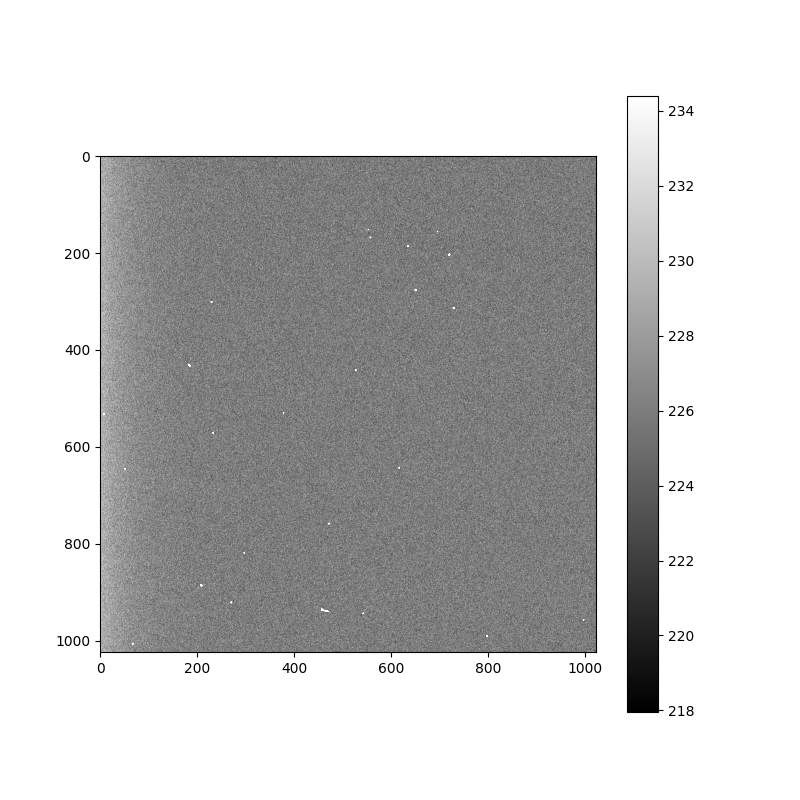

../../data/photo/offsets/p43959f1.fits


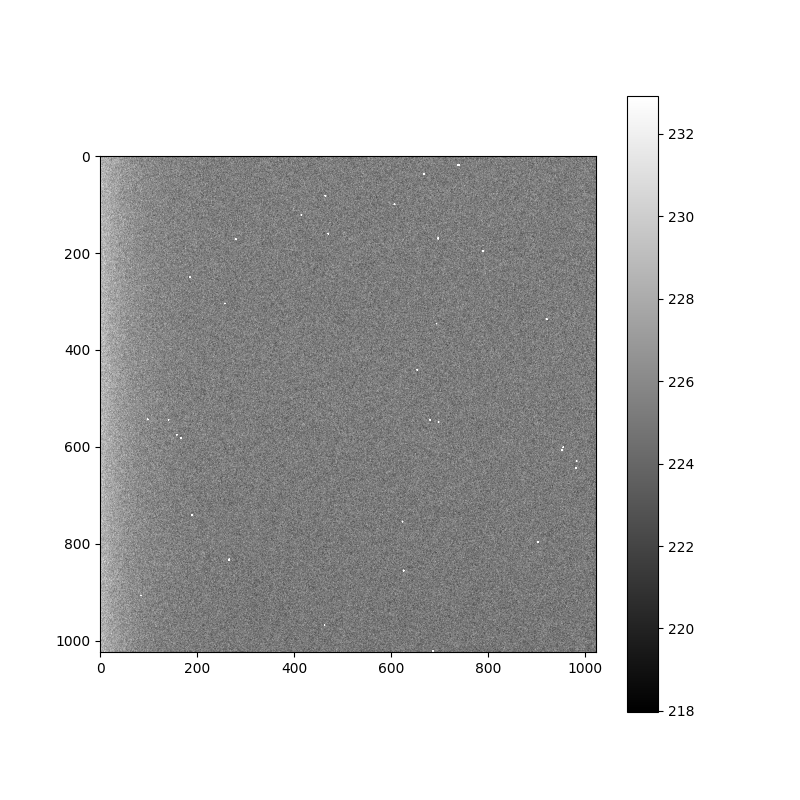

../../data/photo/offsets/p43955f1.fits


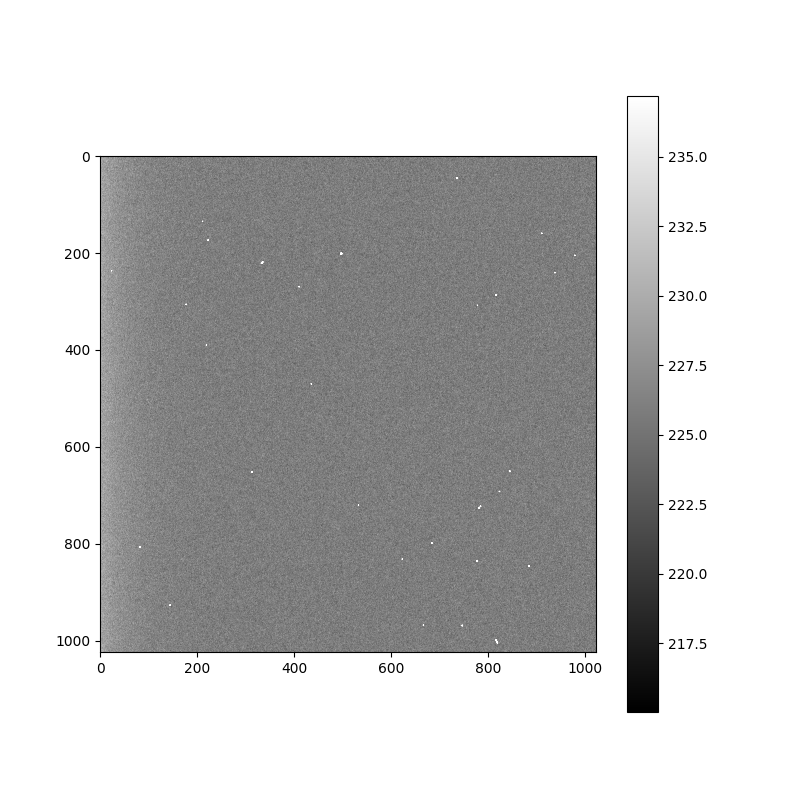

../../data/photo/offsets/p43957f1.fits


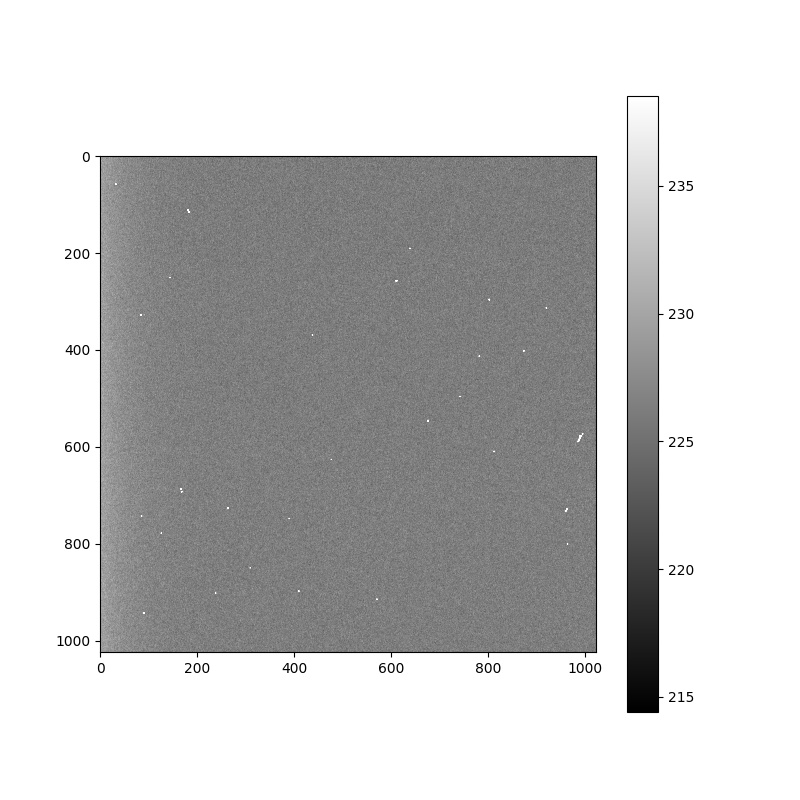

In [11]:
# visualise each image to answer that question 
for file in bias_files:
    print(file)
    # what does it look like?
    data = read_raw_image(file)
    plt.figure(figsize=(8,8))
    # setup the cuts of the image
    vmin,vmax=get_scaling(data)
    plt.imshow(data,cmap=cm.gray,vmin=vmin,vmax=vmax)
    plt.colorbar()
    plt.show()

In [12]:
# OK let's try to make a master_bias, that requires medianning the 5 offset files
# first lets get some stats for the images:
# files=glob.glob('../../data/photo/offsets/p*.fits')

print('filename,                                  ','Npix   ','avg,   ','rms,   ','min,   ','max')
for file in bias_files:
    stats=get_stats(file)
    print(stats)
    
# whats' strange with these numbers?
# Do the stats of the pixels follow a classical gaussian distribution law?

filename,                                   Npix    avg,    rms,    min,    max
['p43958f1.fits', 1048576, 226.02331447601318, 5.395226593262076, 215, 3415]
['p43956f1.fits', 1048576, 226.1780023574829, 4.110583114048485, 216, 1313]
['p43959f1.fits', 1048576, 225.44656372070312, 3.736543015967175, 215, 1576]
['p43955f1.fits', 1048576, 226.10054969787598, 5.538745576701716, 216, 2976]
['p43957f1.fits', 1048576, 226.46543502807617, 6.028690662978478, 216, 3823]


In [13]:
##############
# MASTER_BIAS
##############
# NOW compute the median of the 5 bias and store that into master_bias
# files=glob.glob('../../data/photo/offsets/p*.fits')
nfiles=len(bias_files)
data,header_ori=read_raw_image(bias_files[0],get_header=1)
nx,ny=np.shape(data)
datastore=np.full((nx,ny,nfiles),0.)
# store individual images into an array
for i in range(nfiles):
    datastore[:,:,i]=read_raw_image(bias_files[i])
# compute median of nfiles images
result=np.median(datastore,axis=2)
# target_file='../../data/photo/master_bias.fits'
master_bias_file = output_dir / "master_bias.fits"

# update the OBJECT field of header
header=header_ori
header['OBJECT']='MASTER_BIAS'
# write to file
write_fits_image(master_bias_file,result,header)


wrote  ../../data/photo/REDUCED/master_bias.fits


In [14]:
# Whats the new stats? Any improvement?
master_bias,header1=read_raw_image(master_bias_file,get_header=1)
print('individual biases')
for file in bias_files:
    print(get_stats(file))

print('MASTER_BIAS')
print(get_stats(master_bias_file))

# yay stats of master_bias look much better!!



individual biases
['p43958f1.fits', 1048576, 226.02331447601318, 5.395226593262076, 215, 3415]
['p43956f1.fits', 1048576, 226.1780023574829, 4.110583114048485, 216, 1313]
['p43959f1.fits', 1048576, 225.44656372070312, 3.736543015967175, 215, 1576]
['p43955f1.fits', 1048576, 226.10054969787598, 5.538745576701716, 216, 2976]
['p43957f1.fits', 1048576, 226.46543502807617, 6.028690662978478, 216, 3823]
MASTER_BIAS
['master_bias.fits', 1048576, 226.03228855133057, 1.3249962452232857, 220.0, 236.0]


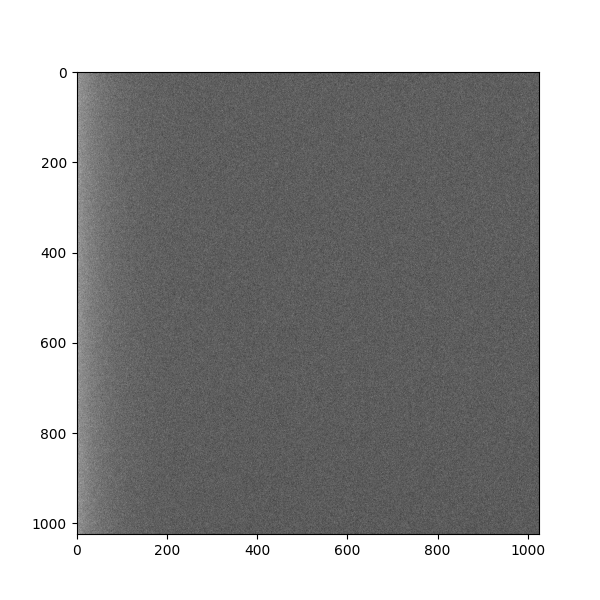

In [15]:
#How does it look?
plt.figure(figsize=(6,6))
plt.imshow(master_bias,cmap=cm.gray)
plt.show()

# Lets make a master flat

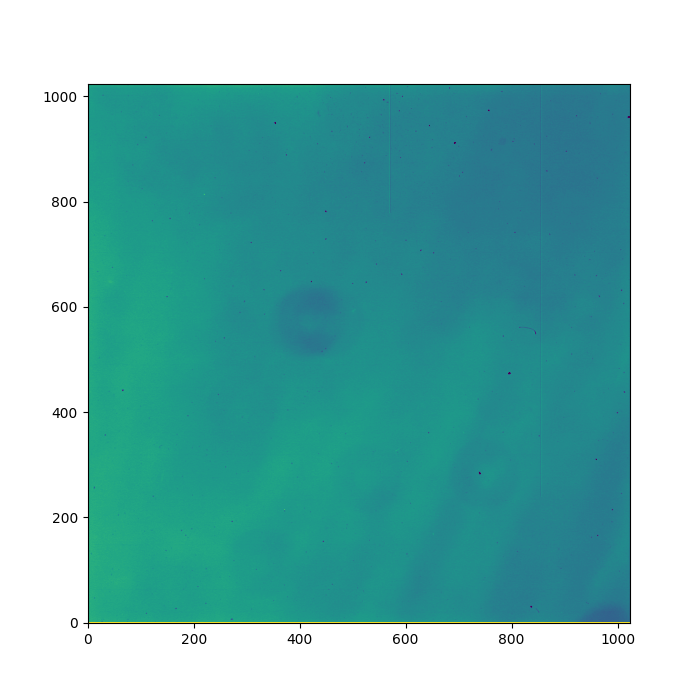

In [16]:
# Now lets make a flat!
# Select flats in one filter 
flat_files = list(flat_dir.glob("B/*.fits"))  

nfiles=len(flat_files)
# what does it look like?
data=read_raw_image(flat_files[1])
plot_image(data)
#plt.figure(figsize=(6,6))
#plt.imshow(data,cmap=cm.gray)
#plt.show()
# discuss the various structures we can see


In [20]:
for file in flat_files:
    print_header(file,keywords_list=['OBJECT','FLTRNM'],l=0)

 flat / B Cousins /  90.17  s                     B Cousins
 flat / B Cousins /  90.17  s                     B Cousins
 flat / B Cousins /  90.17  s                     B Cousins
 flat / B Cousins /  90.17  s                     B Cousins
 flat / B Cousins /  90.17  s                     B Cousins


In [21]:
# check the stats of the flats:
for file in flat_files:
    print('filename,                                  ','Npix   ','avg,   ','rms,   ','min,   ','max')
    print(get_stats(file))
# What differences with the bias stats?

filename,                                   Npix    avg,    rms,    min,    max
['p43933f1.fits', 1048576, 13196.5179977417, 1638.4209188126415, 2335, 65535]
filename,                                   Npix    avg,    rms,    min,    max
['p43937f1.fits', 1048576, 11515.656428337097, 1444.4436680076742, 2026, 59780]
filename,                                   Npix    avg,    rms,    min,    max
['p43935f1.fits', 1048576, 11959.858138084412, 1500.175532746047, 2149, 62105]
filename,                                   Npix    avg,    rms,    min,    max
['p43939f1.fits', 1048576, 11049.631291389465, 1389.4026678988967, 2012, 65535]
filename,                                   Npix    avg,    rms,    min,    max
['p43941f1.fits', 1048576, 10542.076983451843, 1320.3234805042289, 1851, 54500]


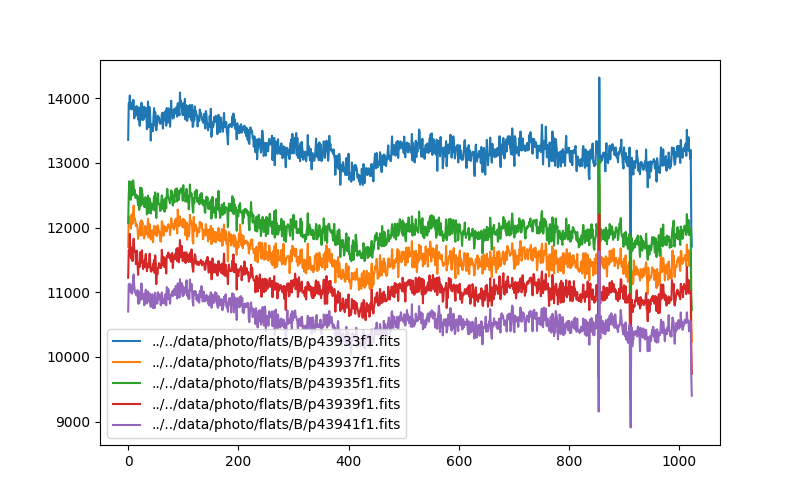

In [22]:
# plot the central line of each flat:
plt.figure(figsize=(8,5))
# select the central line
iline=511
for file in flat_files:
    data=read_raw_image(file)
    plt.plot(data[iline,:],label=file)
plt.legend()
plt.show()

# what do you notice?

In [23]:
# Remove the master_bias from each flat, then compute the normalized flats, where each flat is divided by its median:
# Read the bias image 
bias=read_raw_image(master_bias_file)
# reduced the flatfield (remove the bias)
for file in flat_files:
    data,header=read_raw_image(file,get_header=1)
    data=data-bias # Bias subtraction!
    data=data/np.median(data) # rescaling so that median(data)=1
    base_name = file.stem # to select the base name of the file (without path and extension)
    name_output = output_dir / f"{base_name}_B_norm.fits" #add a name and extention, carry the name of the filter
    write_fits_image(name_output,data,header)

wrote  ../../data/photo/REDUCED/p43933f1_B_norm.fits
wrote  ../../data/photo/REDUCED/p43937f1_B_norm.fits
wrote  ../../data/photo/REDUCED/p43935f1_B_norm.fits
wrote  ../../data/photo/REDUCED/p43939f1_B_norm.fits
wrote  ../../data/photo/REDUCED/p43941f1_B_norm.fits


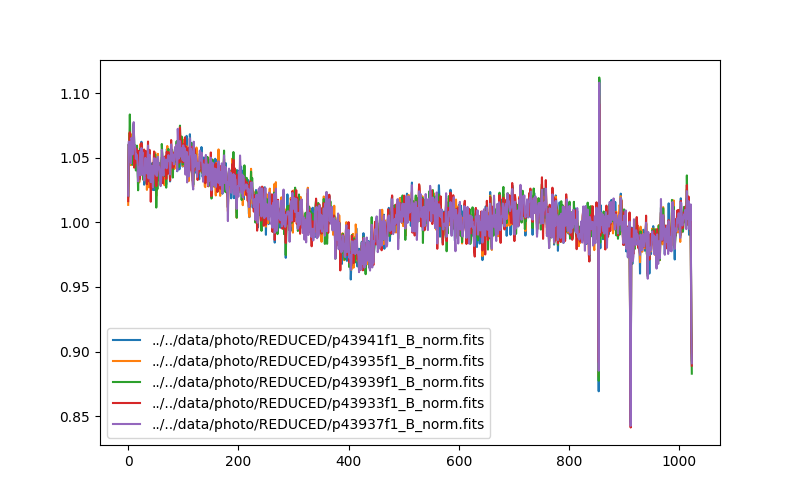

In [24]:
# now plot these normalized flats:
# plot the central line of each flat:
# files=glob.glob('../../data/photo/flats/B/p*.fits.norm')
files = list(output_dir.glob("*B_norm.fits"))  
plt.figure(figsize=(8,5))
iline=511
for file in files:
    data=read_raw_image(file)
    plt.plot(data[iline,:],label=file)
plt.legend()
plt.show()
    

In [25]:
# then median the normalized flats to get the master_flat in the considered filter
files = list(output_dir.glob("*B_norm.fits"))  
nfiles=len(files)
data,header_ori=read_raw_image(files[0],get_header=1)
nx,ny=np.shape(data)
datastore=np.full((nx,ny,nfiles),0.)
# store individual images into an array
for i in range(nfiles):
    datastore[:,:,i]=read_raw_image(files[i])
    
# compute median of nfiles images
result=np.median(datastore,axis=2)
# target_file='../../data/photo/master_flat_V.fits'
# This name should carry information on the filter so we don't mix things
target_file = output_dir / 'master_flat_B.fits'
# update the OBJECT field of header (its not mandatory but will help when
# we try to make sense of / analyse the data / its very late / we did not sleep much
# / and everybody is tired)
header=header_ori
header['OBJECT']='MASTER_FLAT'
# write to file
write_fits_image(target_file,result,header)

wrote  ../../data/photo/REDUCED/master_flat_B.fits


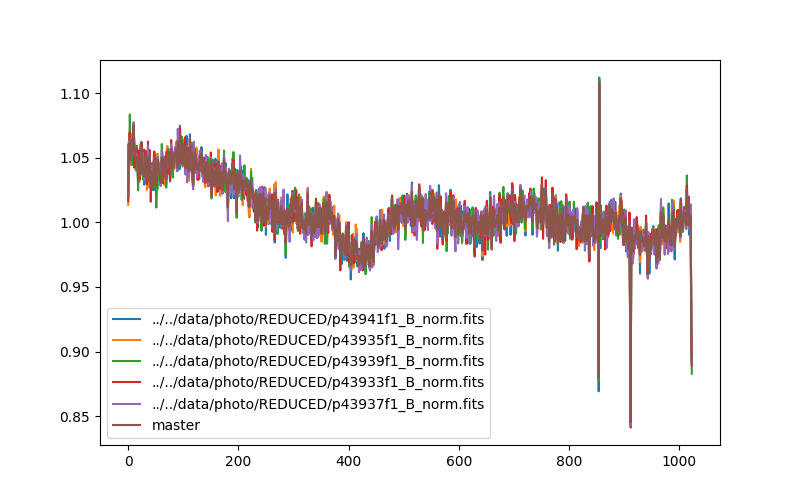

In [26]:
# now plot normed flats as above and overplot master
files = list(output_dir.glob("*B_norm.fits"))  
plt.figure(figsize=(8,5))
iline=511
offset=0
for file in files:
    data=read_raw_image(file)
    plt.plot(data[iline,:]+offset,label=file)
    offset=offset#+0.05

data=read_raw_image(target_file)
plt.plot(data[iline,:]+offset,label='master')
plt.legend()
plt.show()

# Lets reduce the science images

In [29]:
# Now reduce the observed images:
# 1=> subtract bias
# 2=> divide by flat WITH THE CORRESPONDING FILTER!!

# set the directory with the files to be reduced and the filter 
raw_dir = data_dir / "M1"
files = list(raw_dir.glob("*.fits"))  
filter_target='B Cousins'
      
# read the master bias and flat in the corresponding filter
file_bias = output_dir / "master_bias.fits"
bias = read_raw_image(file_bias) 
file_flat = output_dir / "master_flat_B.fits"
master_flat=read_raw_image(file_flat)

nfiles=len(files)
for file in files:
    data,header=read_raw_image(file,get_header=1)
    print(file)
    print(header['FLTRNM'])
    #filter_obs=header['FLTRNM']
    filter_obs = header['FLTRNM']
    if(filter_obs.find(filter_target)>=0): # this checks that the filters match
        print('reducing ',file, filter_obs)
        # bias=read_raw_image('../../data/photo/master_bias.fits')
        # master_flat=read_raw_image('../../data/photo/master_flat_B.fits')
        # THE IMPORTANT, KEY PART!!!
        ##########################
        reduced=(data-bias)/master_flat
        ##########################
        # generate the new filenames for the reduced images:
        reduced_file = output_dir / f"{file.stem}_reduced.fits"
        print(reduced_file)
        write_fits_image(reduced_file,reduced,header)

# do this for each filter or automatize

../../data/photo/M1/p43952f1.fits
                    B Cousins
reducing  ../../data/photo/M1/p43952f1.fits                     B Cousins
../../data/photo/REDUCED/p43952f1_reduced.fits
wrote  ../../data/photo/REDUCED/p43952f1_reduced.fits
../../data/photo/M1/p43950f1.fits
                    R Cousins
../../data/photo/M1/p43946f1.fits
                    R Cousins
../../data/photo/M1/p43954f1.fits
                  O3 ohp 5007
../../data/photo/M1/p43948f1.fits
                    R Cousins
../../data/photo/M1/p43953f1.fits
             H Alpha ohp 6565
../../data/photo/M1/p43951f1.fits
                    V Cousins
../../data/photo/M1/p43947f1.fits
                    V Cousins
../../data/photo/M1/p43949f1.fits
                    R Cousins


In [30]:
# Now redo the steps for the Halpha, OIII and B filters of M1
# OR DO a completely different objct, e.g. NGC2392
# => generate master_flat for each filter
# => reduce all Halpha, OIII and B images of M1 (i.e. subtract master_bias, divide by master_flat)
# Then lets RGB compose M1

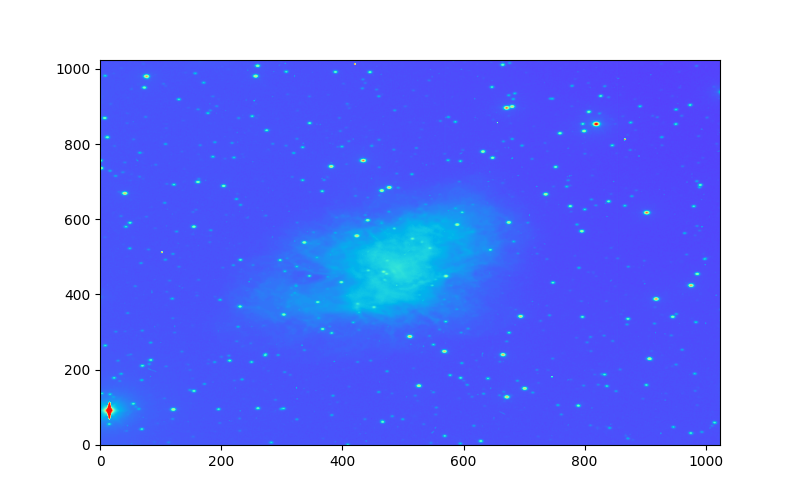

In [33]:
# Let's have a look at a reduced image
files = list(output_dir.glob("*reduced.fits"))  
data=read_raw_image(files[0])

plt.figure(figsize=(8,5))

plt.imshow(data,cmap=cm.rainbow,norm=LogNorm(),origin='lower',aspect='auto')
plt.show()
